## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:

# mostrar las primeras 5 filas de traffic
traffic.head()


,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [5]:
# Examinar la estructura de traffic
traffic.info()
traffic.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo **object** (texto) y deberían ser de tipo **datetime**, por lo que requieren conversión.
- No hay datos ausentes: las 12 columnas tienen 1,004,464 valores no nulos, igual al total de filas.
- El resto de las columnas numéricas (`JamsDelay`, `TrafficIndexLive`, `JamsLengthInKms`, `JamsCount`, `TrafficIndexWeekAgo`, `TravelTimeLivePer10KmsMins`, `TravelTimeHistoricPer10KmsMins` y `MinsDelay`) ya son de tipo **float64**, por lo que no necesitan conversión.

In [6]:
# Examinar la estructura de eco
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


In [7]:
eco['Year'].value_counts()

2023    15
2024    15
Name: Year, dtype: int64

In [8]:
traffic['UpdateTimeUTC'].str[:4].value_counts()

2024    886779
2025    117685
Name: UpdateTimeUTC, dtype: int64

En la estructura del DF eco, se observa que:
Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)` y `Population (M)` son de tipo **object** (texto) y deberían ser de tipo **float64**. Tienen separadores de miles (`.`), comas como separador decimal (`,`) o el símbolo `%`, por lo que requieren limpieza antes de convertirse.
- La columna `Year` ya es de tipo **int64**, por lo que no requiere conversión.
- No hay datos ausentes: las 7 columnas tienen 30 valores no nulos, igual al total de filas.... 

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [9]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={
   'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_hist_per_10kms_mins',
    'MinsDelay': 'mins_delay'
})
    

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [10]:
# Estandarizar los nombres de las columnas de eco
eco.columns = ['year', 'city', 'country', 'city_gdp_capita',
               'unemployment_pct', 'pm25', 'population_m']
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [11]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [12]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.', regex=False).astype(float)
eco['pm25'] = eco['pm25'].astype(str).str.replace(',', '.', regex=False).astype(float)
# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [13]:

# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year
# Verificar cambio
traffic.head(3)


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [14]:

print(traffic['year'].value_counts())
print(eco['year'].value_counts())


2024    886779
2025    117685
Name: year, dtype: int64
2023    15
2024    15
Name: year, dtype: int64


In [15]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0


In [16]:
print(traffic_2024.shape, eco_2024.shape)

(886779, 13) (15, 8)



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


In [17]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
   traffic_2024
    .groupby(['city', 'country', 'year'])
    .agg({
        'jams_delay': 'mean',
        'traffic_index_live': 'mean',
        'jams_length_kms': 'mean',
        'jams_count': 'mean',
        'mins_delay': 'mean',
        'travel_time_live_per_10kms_mins': 'mean',
        'travel_time_hist_per_10kms_mins': 'mean'
    })
    .reset_index()
)

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares La ciudad con el mayor tiempo promedio de tráfico es **Ciudad de México** (`jams_delay` de aproximadamente 2,833), seguida de Tokio, Nueva York y Londres. En el top 10 aparecen ciudades de Asia, Norteamérica, Europa y Latinoamérica (São Paulo también está en la lista).

Hay que aclarar que `jams_delay` es el retraso total sumado en todas las vías monitoreadas, así que favorece a las ciudades grandes con muchas vías. Por eso llama la atención que, en `mins_delay` (retraso por cada 10 km), Manila (2.47) y Estambul (2.46) superan a Ciudad de México (1.86).

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas? Los resultados coinciden con lo que imaginaba: Ciudad de México es una de las ciudades más grandes y congestionadas del mundo, por lo que es lógico que encabece la lista. Lo que sí me llamó la atención es que `jams_delay` es un retraso total, así que favorece a las ciudades grandes, y que en `mins_delay` (retraso por cada 10 km) Manila y Estambul superan a Ciudad de México.

In [18]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False).head(10)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
321,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810
156,istanbul,TUR,2024,1660.789019,45.614786,245.686252,411.145698,2.463699,19.982495,17.518796
159,jakarta,IDN,2024,1379.037135,30.419242,215.228820,295.492817,1.193300,18.098409,16.905109
268,paris,FRA,2024,1320.746822,29.313446,265.865975,324.405534,1.170884,17.658980,16.488097
201,los-angeles,USA,2024,1277.210458,30.446623,341.053551,321.732026,0.790893,13.429048,12.638155



---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


In [19]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = traffic_2024_small.merge(eco_2024_small, on=['city', 'year'], how='inner')


# Mostrar las primeras 5 filas
print(merged.shape)
merged.head()

(15, 14)


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

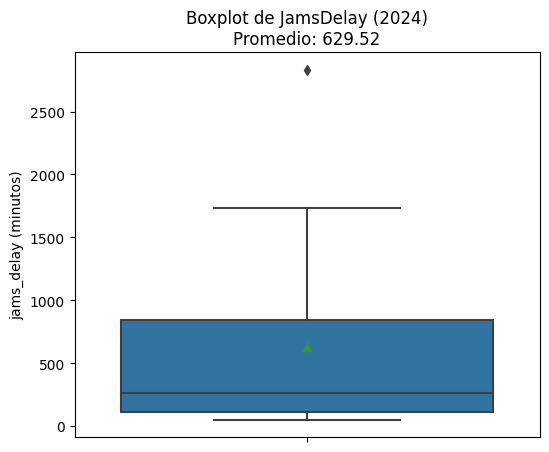

In [20]:

# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
plt.figure(figsize=(6, 5))
sns.boxplot(y=merged['jams_delay'], showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.ylabel('jams_delay (minutos)')
plt.show()


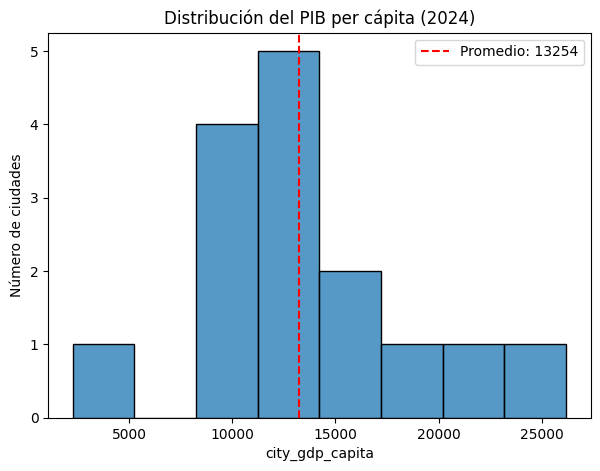

In [21]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)

plt.figure(figsize=(7, 5))
sns.histplot(merged['city_gdp_capita'], bins=8)
# Línea vertical con el promedio del PIB per cápita
mean_gdp = merged['city_gdp_capita'].mean()
plt.axvline(mean_gdp, color='red', linestyle='--', label=f'Promedio: {mean_gdp:.0f}')

plt.title('Distribución del PIB per cápita (2024)')
plt.xlabel('city_gdp_capita')
plt.ylabel('Número de ciudades')
plt.legend()
plt.show()

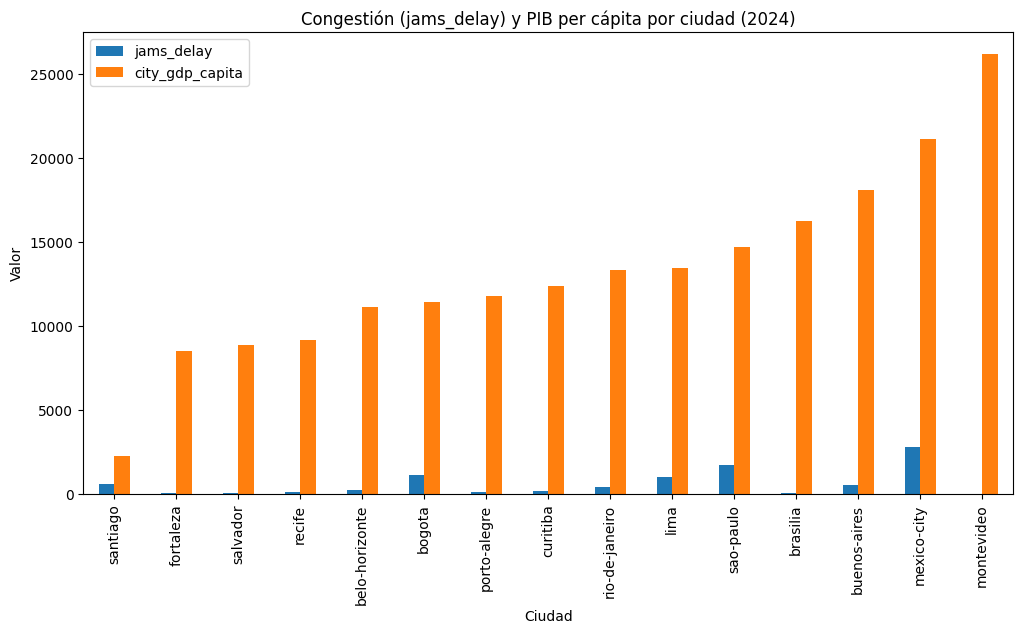

In [22]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged_sorted = merged.sort_values('city_gdp_capita')
merged_sorted.plot(kind='bar', x='city', y=['jams_delay', 'city_gdp_capita'], figsize=(12, 6))

plt.title('Congestión (jams_delay) y PIB per cápita por ciudad (2024)')
plt.xlabel('Ciudad')
plt.ylabel('Valor')
plt.xticks(rotation=90)
plt.show()

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios:
- **Tráfico (boxplot):** el promedio de `jams_delay` (629.52) es mucho mayor que la mediana, lo que indica una distribución sesgada hacia arriba. Ciudad de México aparece como valor atípico (cerca de 2,833).
- **Economía (histograma):** el PIB per cápita promedio es de aproximadamente 13,254. La mayoría de las ciudades se concentra entre 8,000 y 15,000, con una cola hacia la derecha (hasta cerca de 26,000) y una ciudad muy baja (Santiago).
- **Relación entre ambas:** no se observa una relación clara. Las ciudades con mayor PIB per cápita no son necesariamente las más congestionadas: Montevideo tiene el PIB más alto y casi no presenta retraso, mientras que Ciudad de México combina PIB alto con la mayor congestión. Las ciudades más congestionadas (Ciudad de México, São Paulo, Bogotá y Lima) son también de las más grandes, y como `jams_delay` es un retraso total, el tamaño de la ciudad influye en el resultado.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [23]:

# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

# Verificar que el archivo se guardó bien
print(pd.read_csv("ladb_mobility_economy_2024_clean.csv").shape)


(15, 14)


In [24]:
print("Ciudades:", merged['city'].nunique(), "| Países:", merged['country'].nunique())
print(merged[['jams_delay', 'city_gdp_capita', 'unemployment_pct']].corr())

merged[['city', 'jams_delay', 'city_gdp_capita', 'unemployment_pct']].sort_values('jams_delay', ascending=False)

Ciudades: 15 | Países: 7
                  jams_delay  city_gdp_capita  unemployment_pct
jams_delay          1.000000         0.282975         -0.686956
city_gdp_capita     0.282975         1.000000         -0.514407
unemployment_pct   -0.686956        -0.514407          1.000000


,city,jams_delay,city_gdp_capita,unemployment_pct
7,mexico-city,2833.057892,21111.0,3.2
14,sao-paulo,1729.189270,14703.0,8.5
1,bogota,1141.552364,11442.0,10.0
6,lima,1052.292789,13472.0,6.5
13,santiago,629.865318,2277.0,7.8
3,buenos-aires,571.089593,18117.0,7.2
11,rio-de-janeiro,466.064706,13349.0,9.2
0,belo-horizonte,263.047879,11124.0,9.5
4,curitiba,183.469274,12381.0,8.2
9,porto-alegre,139.382830,11801.0,8.7



---

# 🧾 Resumen ejecutivo 

**Contexto y objetivo:** este análisis evalúa cómo se relaciona la movilidad urbana (congestión y tiempos de viaje) con la productividad económica (PIB per cápita) en ciudades de Latinoamérica, para orientar dónde invertir en infraestructura de transporte. Las variables clave son `jams_delay` (retraso total por congestión), `mins_delay`, los tiempos de viaje por cada 10 km, el PIB per cápita y el desempleo.

**Cobertura de datos:** se analizó el año 2024, con 15 ciudades de 7 países (México, Brasil, Colombia, Perú, Chile, Argentina y Uruguay). Los datos de tráfico provienen de TomTom Traffic Index y los económicos de OECD Cities.

**Metodología:** se estandarizaron los nombres de columnas, se convirtieron las fechas a `datetime` y se limpiaron los formatos numéricos de la tabla económica (separadores de miles, comas decimales y símbolo de porcentaje). Se filtró el año 2024, se promedió el tráfico por ciudad y año, y se unieron ambas tablas con una unión INNER por `city` y `year`. Se validó con un boxplot, un histograma y un gráfico de barras.

**Hallazgos iniciales:** la relación entre congestión y PIB per cápita es débil (correlación de 0.28), por lo que no hay un patrón claro. La congestión está muy concentrada: el promedio de `jams_delay` (629.52) es mucho mayor que la mediana (263), y Ciudad de México (2,833) es un valor atípico. La correlación con el desempleo es negativa (-0.69), pero probablemente refleja el tamaño de la ciudad, ya que `jams_delay` es un retraso total y favorece a las ciudades grandes. Santiago muestra un PIB per cápita de 2,277, muy por debajo del resto, y conviene validar ese dato con la fuente.

**Recomendaciones:** Bogotá es la ciudad prioritaria para invertir en infraestructura de transporte: es la tercera más congestionada (`jams_delay` de 1,142), con un PIB per cápita por debajo del promedio (11,442 frente a 13,254) y un desempleo de 10%, el más alto entre las cuatro ciudades más congestionadas. Santiago podría ser otro caso a considerar, pero solo después de validar su dato de PIB. Ciudad de México y São Paulo tienen la mayor congestión, pero su economía es más grande. Con solo 15 ciudades y un año de datos, estos resultados son orientativos y no prueban causalidad.
